# 03 — Exploração e Tratamento de Séries

## Objetivo

Analisar visualmente cada série macroeconômica e tomar decisões sobre dessazonalização, 
transformações logarítmicas e tratamento da pandemia, gerando o dataset final para 
modelagem em `data/processed/`.

## Dados de entrada

`data/raw/series_macroeconomicas.csv` — gerado pelo notebook `02_ingestao.ipynb`. 
Frequência mensal, janela 2000-01 a 2025-12.

## Decisões metodológicas

- **Dessazonalização**: aplicada apenas a séries que apresentem padrão sazonal claro, 
  via X-13 ARIMA-SEATS.
- **Transformação log**: aplicada a séries em níveis (preços, índices), preservando 
  séries já em variação percentual (IPCA, Selic, expectativa de inflação).
- **Pandemia**: dummies mensais para março/2020 a setembro/2020 (período de maior 
  distorção), a ser confirmado por análise visual.

## Outputs

- `data/processed/series_tratadas.csv` — séries finais
- `outputs/figures/01_series_nivel.png` — visão geral
- `outputs/figures/02_*.png` — gráficos diagnósticos por série

## 1. Carregamento dos dados

Carregamos o CSV consolidado no notebook anterior.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Configurações
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['figure.dpi'] = 100

DATA_RAW = Path('../data/raw')
DATA_PROCESSED = Path('../data/processed')

# Carrega o CSV salvo no Bloco 2
df = pd.read_csv(
    DATA_RAW / 'series_macroeconomicas.csv',
    index_col=0,
    parse_dates=True
)

print(f"Shape: {df.shape}")
print(f"Período: {df.index.min().strftime('%Y-%m')} a {df.index.max().strftime('%Y-%m')}")
df.head()

Shape: (312, 9)
Período: 2000-01 a 2025-12


,ibcbr,ipca,selic,cambio,commodities,m1,prod_industrial,credito_total,exp_ipca_12m
Date,,,,,,,,,
2000-01-01,NaN,0.62,18.94,1.8037,51.41,NaN,NaN,289197,NaN
2000-02-01,NaN,0.13,18.87,1.7753,50.22,NaN,NaN,287573,NaN
2000-03-01,NaN,0.22,18.85,1.7420,49.51,NaN,NaN,286084,NaN
2000-04-01,NaN,0.42,18.62,1.7682,50.31,NaN,NaN,291609,NaN
2000-05-01,NaN,0.01,18.51,1.8279,53.18,NaN,NaN,312232,NaN


## 2. Análise visual em nível

Antes de qualquer teste estatístico, inspecionamos cada série visualmente. 
Boa parte dos problemas em séries temporais (outliers, quebras estruturais, 
sazonalidade, mudanças de regime) é detectável a olho nu e mais confiável 
do que testes formais aplicados às cegas.

Procuramos:

- **Tendência**: persistência de movimento crescente ou decrescente
- **Sazonalidade**: padrão que se repete a cada 12 meses
- **Quebras estruturais**: saltos súbitos não-recorrentes
- **Mudanças de regime**: alteração na volatilidade ou no nível médio
- **Outliers**: pontos anômalos isolados, especialmente em torno da pandemia (2020-21)

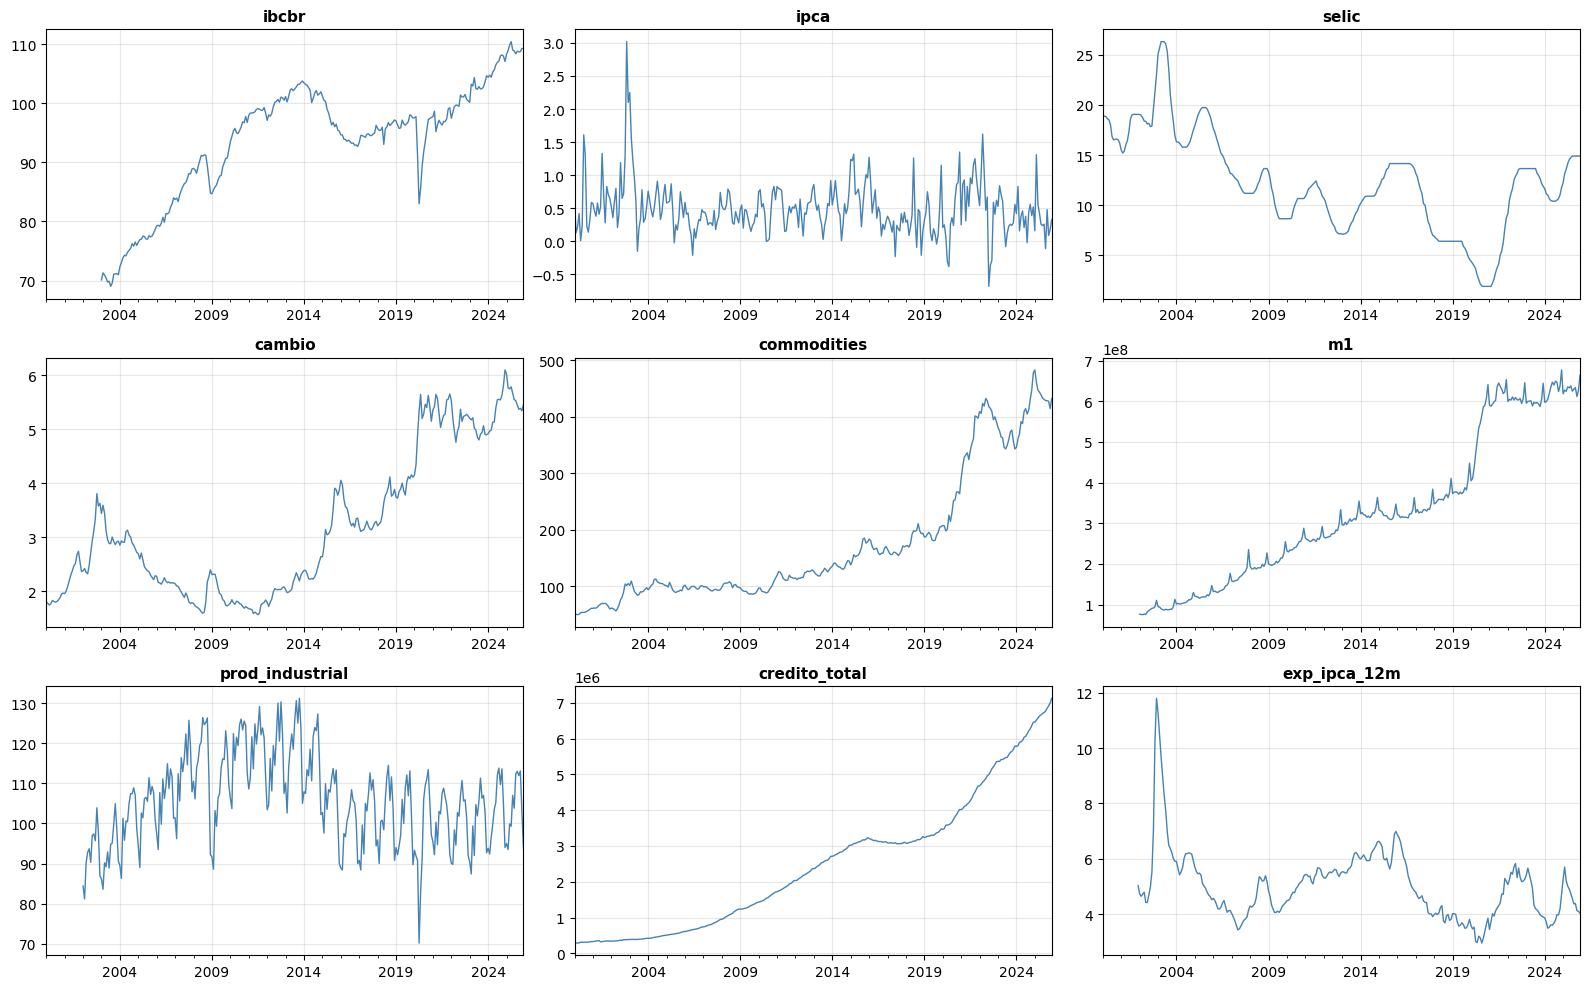

In [2]:
# Plot de todas as séries em uma grade
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 10))
axes = axes.flatten()  # transforma matriz 3x3 em vetor de 9 eixos

cols = df.columns.tolist()
for i, col in enumerate(cols):
    ax = axes[i]
    df[col].plot(ax=ax, color='steelblue', linewidth=1)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/01_series_nivel.png', dpi=120, bbox_inches='tight')
plt.show()

### 2.1 IBC-Br (proxy do PIB mensal)

Tendência crescente clara ao longo de todo o período. A queda em 2020-Q2 (pandemia) 
é a anomalia mais óbvia da série, com recuperação em formato de "V" — em 2021 o nível 
já havia voltado ao patamar pré-pandemia. A série já vem dessazonalizada da fonte 
(BCB SGS 24364 é a versão *seasonally adjusted*), o que se confirma visualmente pela 
ausência de padrão sazonal regular.

### 2.2 IPCA (inflação mensal)

Aparenta estacionariedade em nível, com média estável próxima de 0,5% ao mês. Dois 
episódios merecem destaque:

- **2002-2003**: pico positivo associado à "crise de credibilidade" que precedeu a 
  primeira eleição de Lula, com desancoragem de expectativas, fuga de capitais e 
  pressão cambial repassada a preços.
- **2021-2022**: pico positivo expressivo, com inflação mensal superando 1% diversas 
  vezes. Combinação de choques de oferta (gargalos pós-pandemia), choque de 
  commodities (energia, alimentos), e desvalorização cambial.

A volatilidade do IPCA também parece aumentar em 2020-2022, o que pode demandar 
tratamento ou consideração em modelos com heterocedasticidade condicional.

### 2.3 Selic (taxa básica de juros)

Ciclos visíveis de aperto e afrouxamento monetário. O nível médio caiu ao longo do 
período — de patamares próximos a 20% no início dos anos 2000 para mínimos históricos 
em 2020-2021 (cerca de 2% a.a.) — refletindo a consolidação do regime de metas e a 
queda da inflação estrutural.

**Atenção conceitual:** essa queda do nível médio não é uma "tendência" no sentido 
estatístico (componente não-estacionário que se prolongaria indefinidamente), mas 
sim uma transição entre regimes macroeconômicos. Para o teste ADF, isso pode gerar 
não-rejeição da hipótese nula mesmo quando a série é estacionária por partes — ponto 
a observar no Bloco 4.

### 2.4 Câmbio (R$/US$)

Tendência de depreciação cambial ao longo do período, com episódios marcantes de 
estresse:

- 2002: crise pré-Lula
- 2008-2009: crise financeira global
- 2015-2016: recessão Dilma e choque político
- 2020: pandemia

O regime cambial parece distinto antes e depois de 2014: até essa data o câmbio 
oscilava em torno de R$ 2,00-3,00; após 2014 estabiliza-se em patamares acima de 
R$ 4,00, refletindo fim do superciclo de commodities e mudança no balanço de pagamentos.

### 2.5 IC-Br (índice de commodities BCB em BRL)

Comportamento relativamente estável até 2019, com leve tendência de alta. A partir 
de 2020 há **disparo expressivo**, com o índice mais que dobrando entre 2020 e 2022. 
Reflete combinação de: (i) choques globais de preços de commodities pós-pandemia, 
(ii) desvalorização cambial (o índice está em BRL, então depreciação do real amplifica 
preços em moeda nacional), (iii) guerra Rússia-Ucrânia em 2022.

### 2.6 M1 (agregado monetário)

Tendência clara de crescimento, com **sazonalidade visualmente evidente**: picos 
recorrentes em fim de ano, explicados pela injeção de liquidez via 13º salário, PLR 
e bônus de fim de ano. Salto expressivo de nível em 2020, refletindo as medidas de 
expansão monetária e fiscal durante a pandemia (auxílio emergencial, medidas de 
preservação do emprego, crédito extraordinário).

**Tratamento necessário:** dessazonalização via X-13 ARIMA-SEATS.

### 2.7 Produção industrial

Série com **sazonalidade densa e óbvia** (oscilações regulares dentro de cada ano) 
e **mudança de regime de volatilidade em 2014-2015**: antes desse período a produção 
oscilava em patamar mais elevado (95-130); depois cai para faixa menor (85-115), 
refletindo a estagnação industrial conhecida como "década perdida" da indústria 
brasileira. Queda dramática em 2020-Q2 e recuperação parcial.

**Tratamento necessário:** dessazonalização via X-13 ARIMA-SEATS. A mudança de regime 
de volatilidade pode justificar análise de robustez restringindo o modelo ao período 
pós-2015.

### 2.8 Crédito total

Tendência forte e suave de crescimento. Possíveis inflexões a investigar:

- **2007-2008**: aceleração consistente com o boom de crédito consignado e expansão 
  do BNDES no período pré-crise.
- **2015-2016**: desaceleração compatível com a recessão e mudanças no marco do 
  crédito direcionado.

A magnitude expressiva (R$ 7 trilhões em 2025) e o crescimento sustentado refletem 
tanto evolução real quanto efeito de inflação acumulada. Em log + diferenciação 
(Bloco 4), o crescimento real fica isolado.

### 2.9 Expectativa de inflação 12 meses (Focus)

Série bem comportada após o término da crise de 2002-2003. Pico isolado em 2002-2003 
(desancoragem pré-Lula) destoa fortemente do restante. **Observação importante:** 
no período pós-pandemia, as expectativas subiram em 2021-2022 e depois recuaram, mas 
**não voltaram ao nível 2017-2019**. Esse fenômeno de desancoragem parcial das 
expectativas é tema central no debate macroeconômico brasileiro de 2024-2025.

A inclusão desta série é a principal novidade metodológica em relação à monografia 
original. A expectativa de inflação é o principal candidato a resolver o *price puzzle* 
identificado no trabalho anterior.

## 3. Síntese e implicações para o tratamento

| Série | Sazonalidade | Tendência forte | Quebra estrutural | Tratamento |
|-------|:------------:|:---------------:|:-----------------:|------------|
| ibcbr | ❌ (já SA) | ✅ | Pandemia (2020) | Dummy COVID + log + diff |
| ipca | A verificar | ❌ | Crise 2002, COVID | Dummy COVID; truncar 2003? |
| selic | ❌ | Mudança de regime | Diversos ciclos | Diff (provavelmente) |
| cambio | A verificar | ✅ | 2014, COVID | Dummy COVID + log + diff |
| commodities | A verificar | ✅ pós-2020 | 2020 (disparo) | Dummy COVID + log + diff |
| m1 | ✅ óbvia | ✅ | COVID | X-13 + log + diff |
| prod_industrial | ✅ óbvia | Mudança 2014-15 | COVID | X-13 + dummy COVID + diff |
| credito_total | A verificar | ✅ | 2007-08, 2015-16 | X-13? + log + diff |
| exp_ipca_12m | A verificar | ❌ pós-2003 | 2002-03, 2020-22 | Dummy COVID; truncar 2003 |

**Decisões consolidadas para os próximos passos:**

1. **Janela do modelo principal**: 2003-01 a 2025-12 (limitada pelo início do IBC-Br)
2. **Janela de robustez**: 2005-01 a 2025-12 (exclui resíduos da crise 2002-2003)
3. **Pandemia**: dummies mensais para o período de maior distorção (provavelmente 
   2020-03 a 2020-09, a refinar)
4. **Dessazonalização**: aplicação obrigatória em `m1` e `prod_industrial`; 
   verificação por X-13 em `commodities`, `credito_total` e `cambio`
5. **Transformações log**: aplicadas a séries em níveis com tendência forte 
   (ibcbr, cambio, commodities, m1, prod_industrial, credito_total)
6. **Quebras estruturais**: a investigar formalmente no Bloco 4 via testes de 
   Bai-Perron ou Zivot-Andrews

## 4. Dessazonalização via X-13 ARIMA-SEATS

Aplicamos o X-13 ARIMA-SEATS, padrão internacional para dessazonalização de séries 
econômicas, mantido pelo U.S. Census Bureau e usado pelo BCB para produzir as séries 
oficiais dessazonalizadas (incluindo o próprio IBC-Br).

**Séries candidatas a dessazonalização** (com base na inspeção visual):

- `m1`: sazonalidade óbvia (picos de fim de ano por 13º, PLR, bônus)
- `prod_industrial`: sazonalidade densa visível
- `commodities`, `credito_total`, `cambio`: sem padrão sazonal visível, mas testamos 
  via X-13 para confirmar

**Séries que não dessazonalizamos:**

- `ibcbr`: já vem dessazonalizado da fonte (BCB SGS 24364 é a versão SA)
- `ipca`, `selic`, `exp_ipca_12m`: séries em variação percentual ou taxas, sem 
  sazonalidade econômica esperada

O X-13 escolhe automaticamente entre decomposição multiplicativa e aditiva, e também 
detecta se há sazonalidade significativa. Se não houver, retorna a série original.

In [3]:
from statsmodels.tsa.x13 import x13_arima_analysis
import warnings

def dessazonalizar(serie, nome):
    """
    Aplica X-13 ARIMA-SEATS a uma série temporal mensal.
    
    Retorna a série dessazonalizada e um dicionário com diagnósticos.
    Se o X-13 falhar (série muito curta, problemas numéricos), retorna a série original.
    """
    # X-13 não aceita NaN, então cortamos NaNs do início/fim
    serie_limpa = serie.dropna()
    
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            resultado = x13_arima_analysis(
                serie_limpa,
                freq='M',           # frequência mensal
                outlier=True,       # X-13 detecta outliers automaticamente
                print_stdout=False
            )
        
        serie_sa = resultado.seasadj
        # Reinjeta os NaNs originais para manter o índice completo
        serie_sa_completa = serie_sa.reindex(serie.index)
        
        diagnostico = {
            'nome': nome,
            'sucesso': True,
            'n_obs': len(serie_limpa),
        }
        return serie_sa_completa, diagnostico
    
    except Exception as e:
        print(f"  ⚠ X-13 falhou em {nome}: {e}")
        return serie, {'nome': nome, 'sucesso': False, 'erro': str(e)}

In [4]:
# Séries candidatas
series_para_testar = ['m1', 'prod_industrial', 'commodities', 'credito_total', 'cambio']

# Aplica X-13 e guarda resultados em DataFrame paralelo
df_sa = df.copy()  # cópia para preservar o original

print("=== Aplicando X-13 ARIMA-SEATS ===\n")
for col in series_para_testar:
    print(f"Processando {col}...")
    serie_sa, diag = dessazonalizar(df[col], col)
    df_sa[col] = serie_sa
    print(f"  Sucesso: {diag['sucesso']}, observações: {diag.get('n_obs', 0)}\n")

=== Aplicando X-13 ARIMA-SEATS ===

Processando m1...
  Sucesso: True, observações: 288

Processando prod_industrial...
  Sucesso: True, observações: 288

Processando commodities...
  Sucesso: True, observações: 312

Processando credito_total...
  Sucesso: True, observações: 312

Processando cambio...
  Sucesso: True, observações: 312



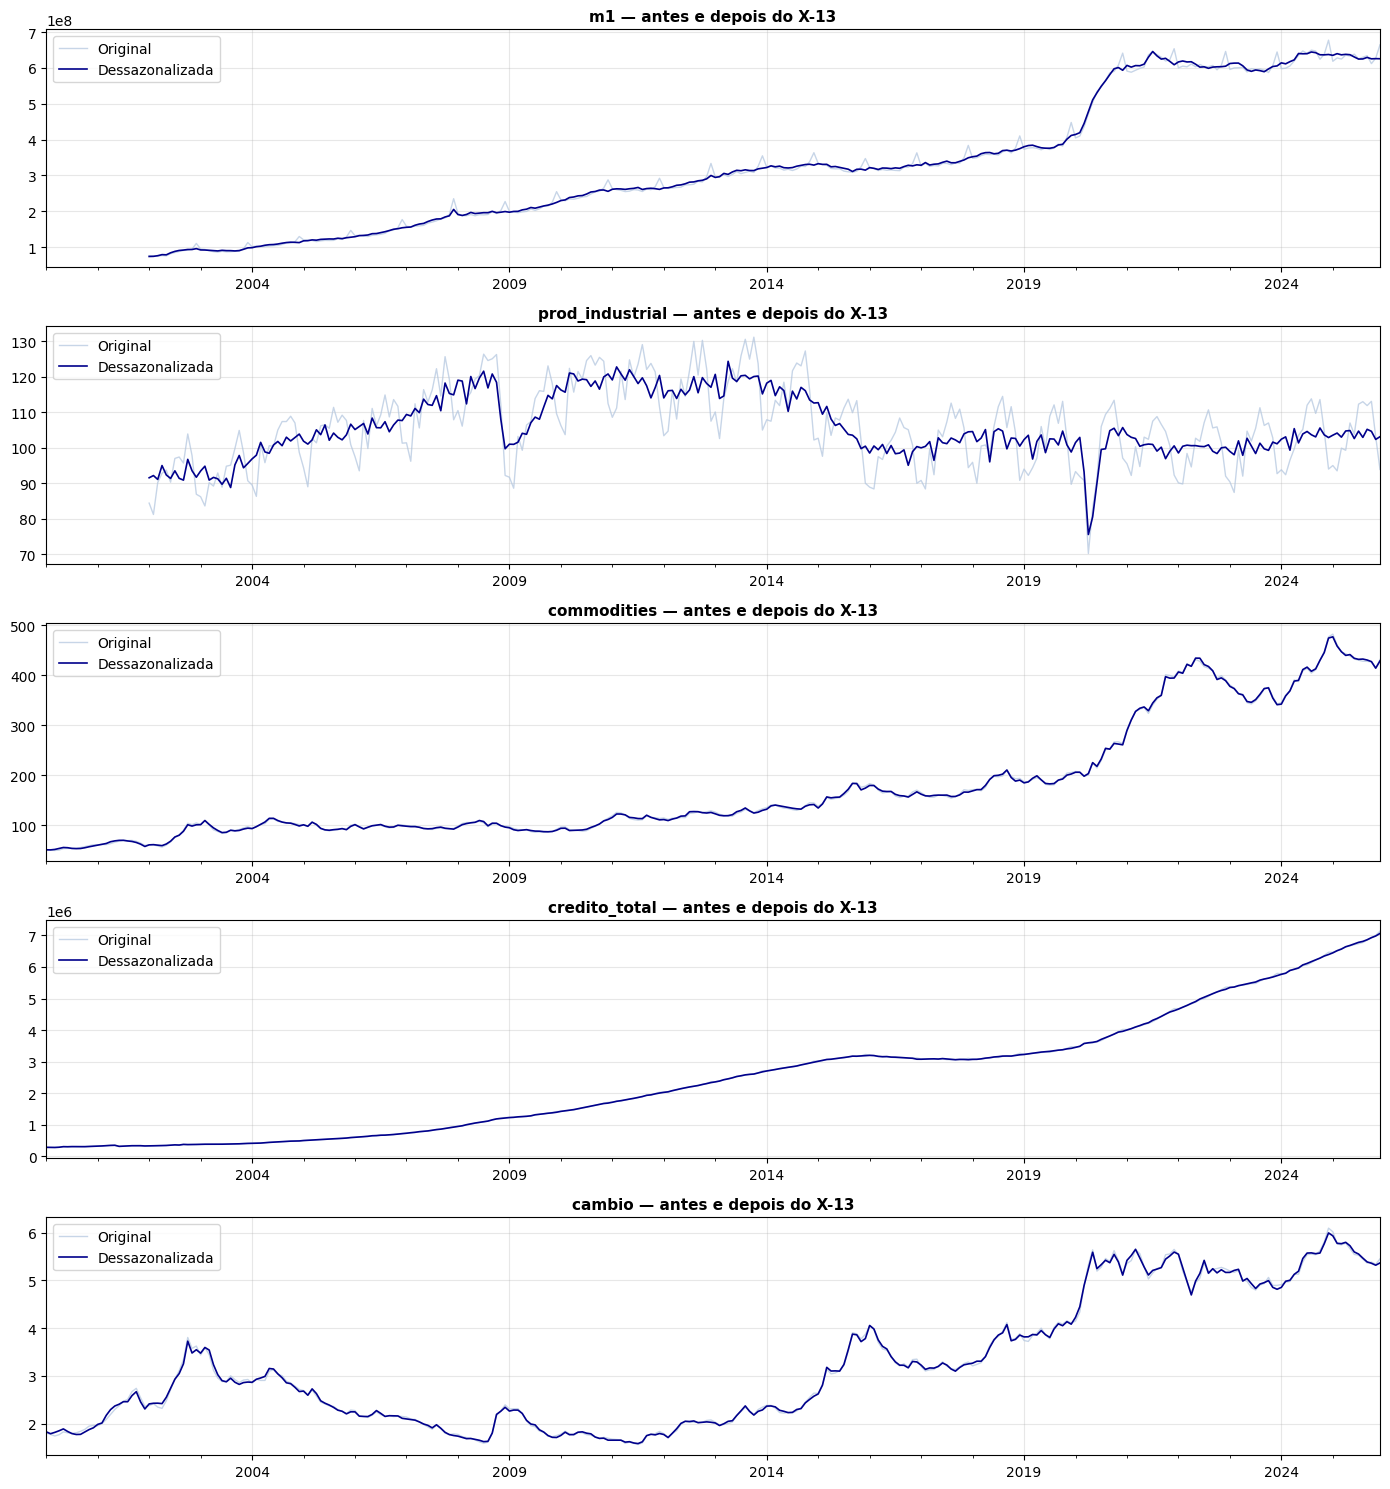

In [5]:
# Compara visualmente as séries originais e dessazonalizadas
fig, axes = plt.subplots(nrows=len(series_para_testar), ncols=1, 
                        figsize=(14, 3 * len(series_para_testar)))

for i, col in enumerate(series_para_testar):
    ax = axes[i]
    df[col].plot(ax=ax, color='lightsteelblue', alpha=0.7, 
                 linewidth=1, label='Original')
    df_sa[col].plot(ax=ax, color='darkblue', linewidth=1.2, 
                    label='Dessazonalizada')
    ax.set_title(f'{col} — antes e depois do X-13', fontsize=11, fontweight='bold')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('../outputs/figures/02_dessazonalizacao.png', dpi=120, bbox_inches='tight')
plt.show()

### 4.1 Resultados da dessazonalização

A aplicação do X-13 ARIMA-SEATS produziu efeitos distintos por série:

| Série | Efeito do X-13 | Decisão |
|-------|---------------|---------|
| `m1` | Remoção clara dos picos regulares de fim de ano (13º, PLR, bônus) | Adotar versão SA |
| `prod_industrial` | Remoção do zigue-zague sazonal denso, restando tendência e ciclos | Adotar versão SA |
| `commodities` | Suavização marginal em picos isolados | Manter série original |
| `credito_total` | Sem alteração visível | Manter série original |
| `cambio` | Suavização marginal em picos isolados | Manter série original |

A ausência de sazonalidade material em commodities, crédito e câmbio é coerente com 
a natureza dessas variáveis: são preços/estoques agregados em mercados sem ciclos 
intra-anuais estruturais. Manter as séries originais nesses casos preserva graus de 
liberdade e evita introduzir variabilidade espúria associada ao processo de 
dessazonalização em séries sem padrão sazonal real.

A decisão final é, portanto, **aplicar X-13 apenas a `m1` e `prod_industrial`**, 
mantendo as demais em sua forma original.

In [6]:
# Reverter dessazonalização das séries onde o efeito foi nulo/marginal
df_sa['commodities'] = df['commodities']
df_sa['credito_total'] = df['credito_total']
df_sa['cambio'] = df['cambio']

print("DataFrame df_sa atualizado:")
print("- m1 e prod_industrial: versões dessazonalizadas")
print("- demais séries: originais")
print(f"\nShape: {df_sa.shape}")

DataFrame df_sa atualizado:
- m1 e prod_industrial: versões dessazonalizadas
- demais séries: originais

Shape: (312, 9)


## 5. Tratamento da pandemia

A pandemia de COVID-19 gerou observações extremamente atípicas, especialmente entre 
março e setembro de 2020. Para o IBC-Br, a queda de abril/2020 representa mais de 3 
desvios-padrão da variação típica da série. Sem tratamento explícito, essas 
observações:

- Inflam artificialmente a variância dos choques no VAR
- Distorcem coeficientes estimados via OLS
- Contaminam funções impulso-resposta com dinâmica não-representativa
- Podem alterar resultados de testes de estacionariedade

### Abordagem adotada

Seguimos a recomendação de **Lenza & Primiceri (2022)** e da literatura aplicada 
recente: introduzir **dummies aditivas (Additive Outliers)** para o período de 
trauma agudo, mantendo o restante do modelo intacto.

**Período coberto:** março a setembro de 2020 (7 dummies).

**Justificativa do período:**
- Início em março/2020: primeira queda mensal expressiva, decretação de pandemia
- Fim em setembro/2020: retorno aproximado ao patamar pré-pandemia no IBC-Br

Efeitos pós-2020 (inflação acelerada em 2021-2022, normalização da Selic) são 
considerados parte legítima da dinâmica macroeconômica que o modelo deve capturar.

### Implementação

As dummies entram como **variáveis exógenas** no VAR (não-endógenas, não respondem 
a choques do sistema). Cada dummy assume valor 1 no respectivo mês e 0 nos demais.

In [7]:
# Define o período de dummies da pandemia
meses_pandemia = pd.date_range(start='2020-03-01', end='2020-09-01', freq='MS')

print(f"Meses cobertos pelas dummies: {len(meses_pandemia)}")
for data in meses_pandemia:
    print(f"  - {data.strftime('%Y-%m')}")

# Cria DataFrame de dummies (uma coluna por mês)
df_dummies = pd.DataFrame(0, index=df_sa.index, columns=[
    f'd_covid_{data.strftime("%Y_%m")}' for data in meses_pandemia
])

# Preenche cada dummy com 1 no mês correspondente
for data in meses_pandemia:
    nome_coluna = f'd_covid_{data.strftime("%Y_%m")}'
    df_dummies.loc[data, nome_coluna] = 1

# Verifica
print(f"\nShape do DataFrame de dummies: {df_dummies.shape}")
print(f"\nVerificação — soma de cada dummy (deve ser 1 cada):")
print(df_dummies.sum())
print(f"\nPrimeiras linhas no período da pandemia:")
print(df_dummies.loc['2020-02':'2020-10'])

Meses cobertos pelas dummies: 7
  - 2020-03
  - 2020-04
  - 2020-05
  - 2020-06
  - 2020-07
  - 2020-08
  - 2020-09

Shape do DataFrame de dummies: (312, 7)

Verificação — soma de cada dummy (deve ser 1 cada):
d_covid_2020_03    1
d_covid_2020_04    1
d_covid_2020_05    1
d_covid_2020_06    1
d_covid_2020_07    1
d_covid_2020_08    1
d_covid_2020_09    1
dtype: int64

Primeiras linhas no período da pandemia:
            d_covid_2020_03  d_covid_2020_04  d_covid_2020_05  \
Date                                                            
2020-02-01                0                0                0   
2020-03-01                1                0                0   
2020-04-01                0                1                0   
2020-05-01                0                0                1   
2020-06-01                0                0                0   
2020-07-01                0                0                0   
2020-08-01                0                0                0   
202

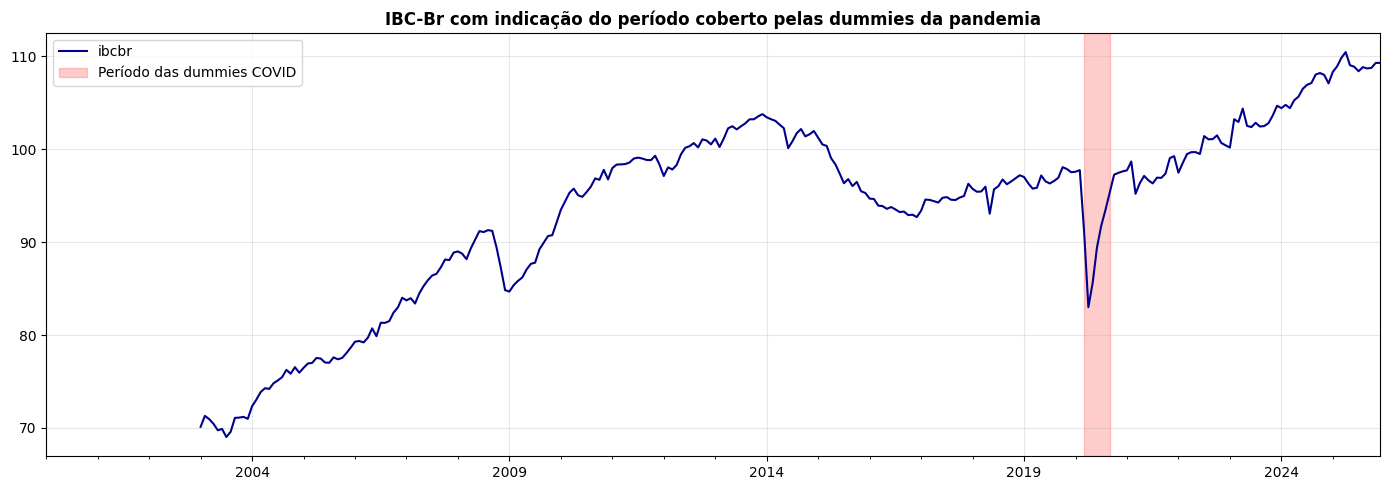

In [8]:
# Plot do IBC-Br com as datas das dummies marcadas
fig, ax = plt.subplots(figsize=(14, 5))

df_sa['ibcbr'].plot(ax=ax, color='darkblue', linewidth=1.5)

# Sombreia o período das dummies
ax.axvspan(meses_pandemia[0], meses_pandemia[-1] + pd.offsets.MonthEnd(0),
           alpha=0.2, color='red', label='Período das dummies COVID')

ax.set_title('IBC-Br com indicação do período coberto pelas dummies da pandemia',
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlabel('')

plt.tight_layout()
plt.savefig('../outputs/figures/03_dummies_covid.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Transformações finais

### 6.1 Transformação logarítmica

Aplicamos logaritmo natural às séries em nível com tendência exponencial. Para 
séries já em formato de taxa ou variação percentual (IPCA, Selic, expectativa de 
inflação), mantemos a escala original.

**Critério de decisão:**

- Séries em nível (preços, índices, estoques) com valores estritamente positivos: 
  aplica log
- Séries em variação percentual ou taxas: mantém escala original

**Justificativa da transformação log:**

1. **Lineariza relações exponenciais:** crescimento composto de PIB, agregados 
   monetários e crédito é naturalmente multiplicativo
2. **Estabiliza variância:** séries com tendência exponencial geralmente apresentam 
   variância crescente; log reduz esse problema
3. **Interpretação:** primeiras diferenças do log são aproximadamente equivalentes 
   a variações percentuais, facilitando interpretação dos resultados do VAR
4. **Convenção da literatura:** padrão em modelos VAR macroeconômicos

**Séries transformadas:** `ibcbr`, `cambio`, `commodities`, `m1`, `prod_industrial`, 
`credito_total`.

**Séries mantidas no nível:** `ipca`, `selic`, `exp_ipca_12m`.

A diferenciação para estacionariedade — quando necessária — será decidida no 
Bloco 4, após os testes formais (ADF, KPSS).

In [9]:
import numpy as np

# Define quais séries recebem log
series_log = ['ibcbr', 'cambio', 'commodities', 'm1', 'prod_industrial', 'credito_total']
series_nivel = ['ipca', 'selic', 'exp_ipca_12m']

# Cria o DataFrame final
df_final = pd.DataFrame(index=df_sa.index)

# Aplica log nas séries selecionadas (prefixo "ln_" para deixar claro)
for col in series_log:
    df_final[f'ln_{col}'] = np.log(df_sa[col])

# Mantém as séries de taxa/variação no nível original
for col in series_nivel:
    df_final[col] = df_sa[col]

print("DataFrame final:")
print(df_final.head())
print(f"\nShape: {df_final.shape}")
print(f"\nColunas:")
for c in df_final.columns:
    print(f"  - {c}")

DataFrame final:
            ln_ibcbr  ln_cambio  ln_commodities  ln_m1  ln_prod_industrial  \
Date                                                                         
2000-01-01       NaN   0.589840        3.939833    NaN                 NaN   
2000-02-01       NaN   0.573969        3.916413    NaN                 NaN   
2000-03-01       NaN   0.555034        3.902175    NaN                 NaN   
2000-04-01       NaN   0.569962        3.918204    NaN                 NaN   
2000-05-01       NaN   0.603168        3.973682    NaN                 NaN   

            ln_credito_total  ipca  selic  exp_ipca_12m  
Date                                                     
2000-01-01         12.574863  0.62  18.94           NaN  
2000-02-01         12.569232  0.13  18.87           NaN  
2000-03-01         12.564041  0.22  18.85           NaN  
2000-04-01         12.583169  0.42  18.62           NaN  
2000-05-01         12.651502  0.01  18.51           NaN  

Shape: (312, 9)

Colunas:
  -

In [10]:
# Junta as dummies de pandemia ao DataFrame final
df_final = df_final.join(df_dummies)

print(f"Shape após adicionar dummies: {df_final.shape}")
print(f"\nNomes das colunas finais:")
for c in df_final.columns:
    print(f"  - {c}")

Shape após adicionar dummies: (312, 16)

Nomes das colunas finais:
  - ln_ibcbr
  - ln_cambio
  - ln_commodities
  - ln_m1
  - ln_prod_industrial
  - ln_credito_total
  - ipca
  - selic
  - exp_ipca_12m
  - d_covid_2020_03
  - d_covid_2020_04
  - d_covid_2020_05
  - d_covid_2020_06
  - d_covid_2020_07
  - d_covid_2020_08
  - d_covid_2020_09


In [11]:
# Janela do modelo principal: 2003-01 a 2025-12 (limitada pelo IBC-Br)
df_modelo = df_final.loc['2003-01-01':'2025-12-01'].copy()

print(f"Período do dataset final:")
print(f"  Início: {df_modelo.index.min().strftime('%Y-%m')}")
print(f"  Fim:    {df_modelo.index.max().strftime('%Y-%m')}")
print(f"  Observações: {len(df_modelo)}")

print(f"\nValores faltantes por coluna:")
print(df_modelo.isna().sum())

Período do dataset final:
  Início: 2003-01
  Fim:    2025-12
  Observações: 276

Valores faltantes por coluna:
ln_ibcbr              0
ln_cambio             0
ln_commodities        0
ln_m1                 0
ln_prod_industrial    0
ln_credito_total      0
ipca                  0
selic                 0
exp_ipca_12m          0
d_covid_2020_03       0
d_covid_2020_04       0
d_covid_2020_05       0
d_covid_2020_06       0
d_covid_2020_07       0
d_covid_2020_08       0
d_covid_2020_09       0
dtype: int64


In [12]:
caminho_saida = DATA_PROCESSED / 'series_tratadas.csv'
df_modelo.to_csv(caminho_saida, index=True, date_format='%Y-%m-%d')

print(f"Arquivo salvo em: {caminho_saida.absolute()}")
print(f"Tamanho: {caminho_saida.stat().st_size / 1024:.1f} KB")

Arquivo salvo em: c:\Users\lucas\Documents\politica-monetaria-br\notebooks\..\data\processed\series_tratadas.csv
Tamanho: 43.9 KB


In [13]:
df_verificacao = pd.read_csv(
    caminho_saida,
    index_col=0,
    parse_dates=True
)

print("Verificação do CSV salvo:")
print(f"Shape: {df_verificacao.shape}")
print(f"Índice é DatetimeIndex? {isinstance(df_verificacao.index, pd.DatetimeIndex)}")
print(f"\nResumo estatístico das variáveis principais:")
print(df_verificacao[['ln_ibcbr', 'ipca', 'selic', 'ln_cambio', 'exp_ipca_12m']].describe())

Verificação do CSV salvo:
Shape: (276, 16)
Índice é DatetimeIndex? True

Resumo estatístico das variáveis principais:
         ln_ibcbr        ipca       selic   ln_cambio  exp_ipca_12m
count  276.000000  276.000000  276.000000  276.000000    276.000000
mean     4.533010    0.468768   11.538623    1.105013      4.963325
std      0.112161    0.351631    4.689810    0.413036      1.150173
min      4.234393   -0.680000    1.900000    0.447183      2.954762
25%      4.478571    0.250000    8.650000    0.751888      4.064524
50%      4.567613    0.440000   11.505000    1.099512      4.928207
75%      4.608810    0.622500   13.975000    1.562066      5.619146
max      4.704585    2.250000   26.320000    1.807797     11.271364


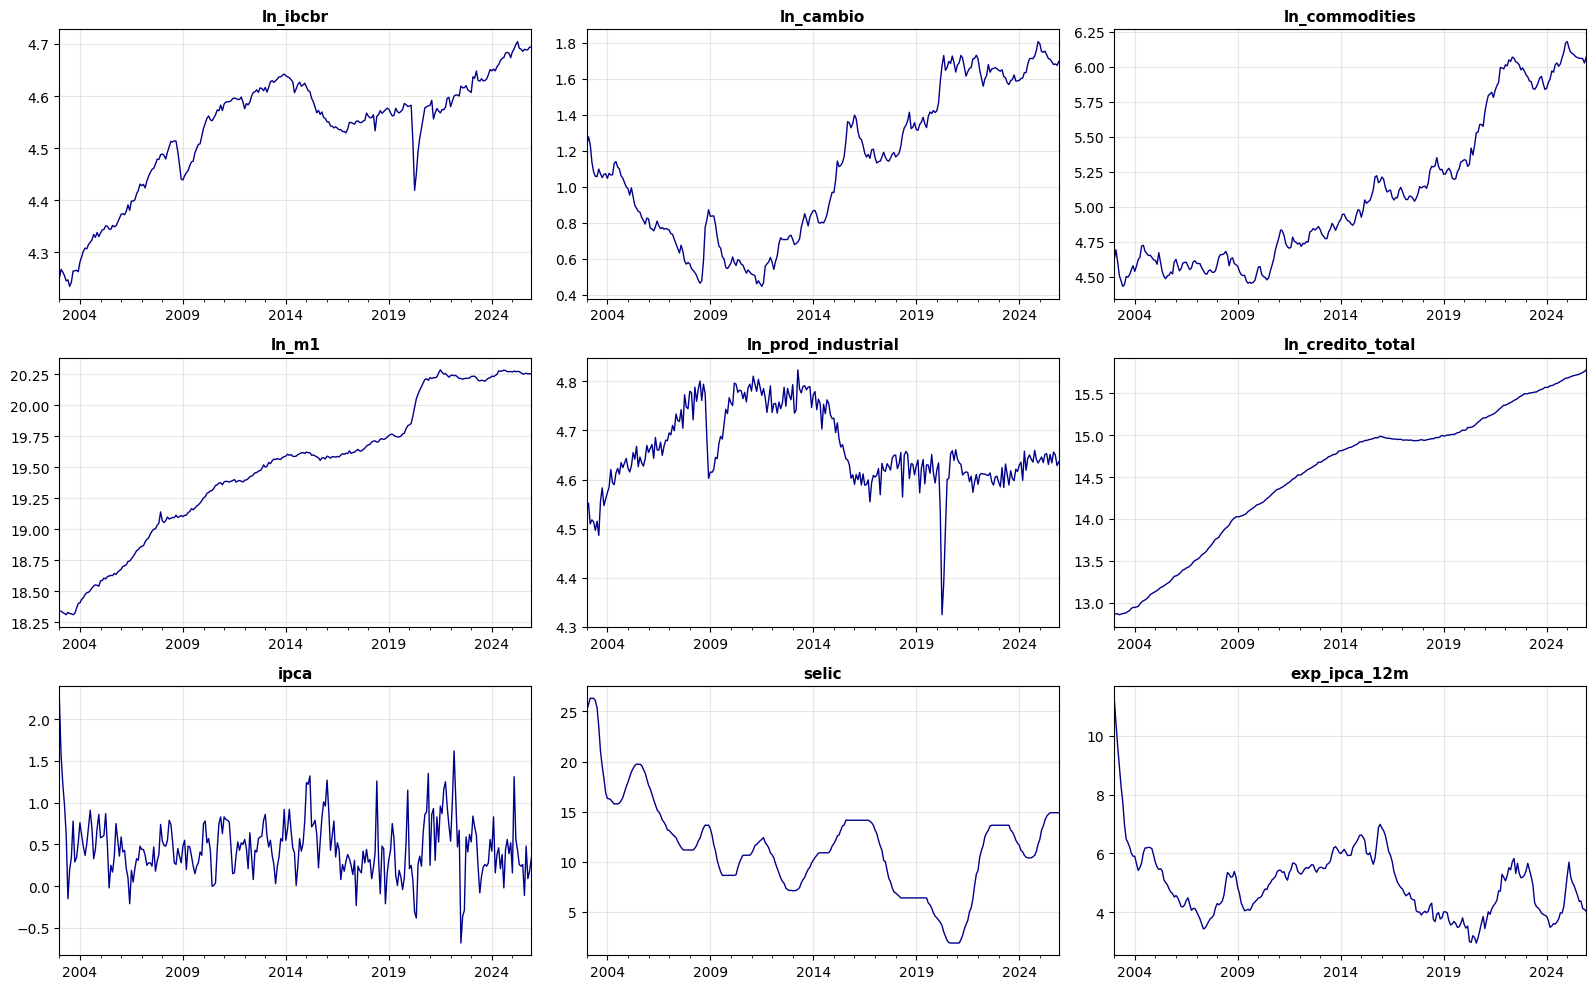

In [14]:
# Plot das séries finais (sem as dummies)
series_modelo = [c for c in df_modelo.columns if not c.startswith('d_')]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(series_modelo):
    ax = axes[i]
    df_modelo[col].plot(ax=ax, color='darkblue', linewidth=1)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/04_series_finais.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Síntese do Bloco 3

Concluímos o tratamento das séries com:

1. **Dessazonalização via X-13 ARIMA-SEATS** aplicada a `m1` e `prod_industrial`. 
   Demais séries mantidas em forma original após verificação de ausência de 
   sazonalidade material.

2. **Dummies de pandemia** (7 variáveis: mar-set/2020) para tratamento explícito 
   do período de trauma agudo.

3. **Transformação logarítmica** aplicada a séries em nível com tendência 
   exponencial. Séries em taxa/variação mantidas no nível.

4. **Janela final:** 2003-01 a 2025-12 (276 observações mensais), limitada pelo 
   início do IBC-Br.

5. **Output:** `data/processed/series_tratadas.csv`, pronto para os testes de 
   estacionariedade e cointegração do Bloco 4.

### O que NÃO fizemos neste bloco

- **Diferenciação:** decisão postergada para o Bloco 4 após testes formais de 
  estacionariedade
- **Testes de cointegração:** Johansen no Bloco 4
- **Testes de quebra estrutural:** Bai-Perron ou Zivot-Andrews no Bloco 4 para 
  investigar formalmente as quebras identificadas visualmente (cambio em 2014, 
  prod_industrial em 2014-2015, credito_total em 2007-2008)